In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join
import numpy as np

from scipy.signal import correlate
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from scipy.stats import zscore
from joblib import Parallel, delayed
import multiprocessing


In [4]:
def bin_and_filter_df(df, bin_size=2.5, min_bin_size=12):
    """
    Bins the dataframe based on 'ts_relative' column using the given bin size.
    Removes bins that have fewer than the specified minimum bin size.

    Parameters:
        df (pd.DataFrame): Input dataframe with a 'ts_relative' column.
        bin_size (float): The size of each bin.
        min_bin_size (int): Minimum number of elements a bin must have to be kept.

    Returns:
        pd.DataFrame: Filtered dataframe with only bins that have at least min_bin_size elements.
    """
    # Create bins
    df['bin'] = (df['ts_relative'] // bin_size).astype(int)

    # Count elements per bin
    bin_counts = df['bin'].value_counts()

    # Filter bins that have at least min_bin_size elements
    valid_bins = bin_counts[bin_counts >= min_bin_size].index

    # Filter original dataframe
    filtered_df = df[df['bin'].isin(valid_bins)].drop(columns=['bin'])

    return filtered_df

In [5]:
def process_connection(conn, df, gateway_df, bin_size_seconds, BOUND_RANGE=1):
    # Filter by current connection
    conn_df = df[df['conn'] == conn].copy()

    # Get the time frame for the specific connection with room for error
    BOUND_RANGE = 1
    conn_ts_start = conn_df['ts_relative'].min()
    conn_ts_end = conn_df['ts_relative'].max() + BOUND_RANGE

    gateway_conn_df = gateway_df[
        (gateway_df['ts_relative'] >= conn_ts_start) & (gateway_df['ts_relative'] <= conn_ts_end)
    ].copy()

    # ---------------------------------------------------------------------
    # 1. Ensuring 'ts_relative' and 'pkt_len' are Numeric
    # ---------------------------------------------------------------------

    gateway_conn_df['ts_relative'] = pd.to_numeric(gateway_conn_df['ts_relative'], errors='coerce')
    gateway_conn_df['pkt_len'] = pd.to_numeric(gateway_conn_df['pkt_len'], errors='coerce')

    conn_df['ts_relative'] = pd.to_numeric(conn_df['ts_relative'], errors='coerce')
    conn_df['pkt_len'] = pd.to_numeric(conn_df['pkt_len'], errors='coerce')

    # Drop rows with invalid (NaN) values
    gateway_conn_df.dropna(subset=['ts_relative', 'pkt_len'], inplace=True)
    conn_df.dropna(subset=['ts_relative', 'pkt_len'], inplace=True)

    # Sort DataFrames by 'ts_relative'
    gateway_conn_df.sort_values('ts_relative', inplace=True)
    conn_df.sort_values('ts_relative', inplace=True)

    # Reset index after sorting
    gateway_conn_df.reset_index(drop=True, inplace=True)
    conn_df.reset_index(drop=True, inplace=True)

    # ---------------------------------------------------------------------
    # 2. Binning Packet Arrivals and Summing 'pkt_len'
    # ---------------------------------------------------------------------

    # Create time bins for gateway_conn_df and relayed_conn_df
    gateway_conn_df.loc[:, 'time_bin'] = (gateway_conn_df['ts_relative'] // bin_size_seconds) * bin_size_seconds
    conn_df.loc[:, 'time_bin'] = (conn_df['ts_relative'] // bin_size_seconds) * bin_size_seconds

    # Sum 'pkt_len' values per bin for gateway and relay
    gateway_sums = gateway_conn_df.groupby('time_bin')['pkt_len'].sum()
    relay_sums = conn_df.groupby('time_bin')['pkt_len'].sum()

    # Create a unified index of all time bins
    all_bins = pd.Index(sorted(set(gateway_sums.index).union(set(relay_sums.index))))

    # Reindex the sums to include all bins, filling missing bins with 0
    gateway_sums = gateway_sums.reindex(all_bins, fill_value=0)
    relay_sums = relay_sums.reindex(all_bins, fill_value=0)

    # ---------------------------------------------------------------------
    # 3. Normalizing the Time Series (Z-Score)
    # ---------------------------------------------------------------------

    # Apply z-score normalization to both time series
    gateway_normalized = zscore(gateway_sums)
    relay_normalized = zscore(relay_sums)

    # Handle cases where standard deviation is zero (to avoid NaNs)
    gateway_normalized = np.nan_to_num(gateway_normalized)
    relay_normalized = np.nan_to_num(relay_normalized)

    # ---------------------------------------------------------------------
    # 4. Computing Cross-Correlation
    # ---------------------------------------------------------------------
    max_corr_value = np.dot(relay_normalized, gateway_normalized) / len(relay_normalized)


    # Get info on volume
    # Compare total volumes
    total_conn = np.sum(conn_df['pkt_len'])
    total_gateway = np.sum(gateway_conn_df['pkt_len'])
    if total_gateway == 0:
        volume_ratio = 0
    else:
        volume_ratio = total_conn / total_gateway  # Check if close to 1

    return (conn, max_corr_value, volume_ratio)



def get_correlation_array_parallel(gateway_df, df, bin_size_seconds=0.1, n_jobs=-1):
    """
    Parallelized version of get_correlation_array using joblib.

    Parameters:
    - gateway_df: pd.DataFrame
    - df: pd.DataFrame
    - bin_size_seconds: float, size of the time bin
    - n_jobs: int, number of parallel jobs (-1 uses all available cores)

    Returns:
    - pd.DataFrame with columns ['conn', 'max_corr', 'vol_ratio']
    """
    connections = df['conn'].unique()
    gateway_df = bin_and_filter_df(gateway_df, 2, 15)

    # Use joblib's Parallel to process connections in parallel
    num_cores = multiprocessing.cpu_count() if n_jobs == -1 else n_jobs
    results = Parallel(n_jobs=num_cores)(
        delayed(process_connection)(conn, df, gateway_df, bin_size_seconds)
        for conn in connections
    )

    return pd.DataFrame(results, columns=['conn', 'max_corr', 'vol_ratio'])

In [232]:
# Get the z score for above setting for background and relay traffic
BASE_PATH = 'data/mouna_test_pcap/mixed_03_01_2025_11_06_27_medium'

relayed_df = pd.read_csv(join(BASE_PATH, "relayed_conn_labeled.csv"))
gateway_df = pd.read_csv(join(BASE_PATH, "proxy_conn.csv"))
background_df = pd.read_csv(join(BASE_PATH, "background_conn_labeled.csv"))


In [233]:
relayed_n = len(relayed_df)
gateway_n = len(gateway_df)

relayed_random_padding = pd.Series(
    np.random.normal(loc=250, scale=125, size=relayed_n).clip(0, 350).round().astype(int),
    index=relayed_df.index
)

gateway_random_padding = pd.Series(
    np.random.normal(loc=0.050, scale=0.01, size=gateway_n).clip(0, 0.1),
    index=gateway_df.index
)

In [6]:
def get_metrics(data):
    # Handle edge cases
    if data.size == 0:
        count = 0
        total_sum = 0
        mean = 0
        median = 0
        minimum = 0
        maximum = 0
        data_range = 0
        variance = 0
        std_dev = 0
    elif data.size == 1:
        count = 1
        total_sum = data
        mean = data
        median = data
        minimum = data
        maximum = data
        data_range = 0
        variance = 0  # Variance is undefined for a single value
        std_dev = 0   # Standard deviation is undefined for a single value
    else:
        # Compute metrics safely when data has at least 2 elements
        count = data.size
        total_sum = np.sum(data)
        mean = np.mean(data)
        median = np.median(data)
        minimum = np.min(data)
        maximum = np.max(data)
        data_range = maximum - minimum
        variance = np.var(data, ddof=1) if data.size > 1 else 0
        std_dev = np.std(data, ddof=1) if data.size > 1 else 0

    metrics = [
        count,        # Count
        total_sum,    # Sum
        mean,         # Mean (Average)
        median,       # Median
        minimum,      # Minimum
        maximum,      # Maximum
        data_range,   # Range
        variance,     # Variance
        std_dev       # Standard Deviation
    ]

    return metrics


def cosine_similarity(a, b):
    mag_product = (np.linalg.norm(a) * np.linalg.norm(b))
    if mag_product == 0:
        return 0
    
    return np.dot(a, b) / mag_product

In [7]:
def get_correlation_array(gateway_df, df, bin_size_seconds=0.1):
    connections = df['conn'].unique()
    # gateway_df = bin_and_filter_df(gateway_df, 2, 15)
    z_scores = []
    for conn in connections:

        # Filter by current connection
        conn_df = df[df['conn'] == conn].copy()

        # Get the time frame for the specific connection with room for error
        BOUND_RANGE = 1
        conn_ts_start = conn_df['ts_relative'].min()
        conn_ts_end = conn_df['ts_relative'].max() + BOUND_RANGE

        gateway_conn_df = gateway_df[
            (gateway_df['ts_relative'] >= conn_ts_start) & (gateway_df['ts_relative'] <= conn_ts_end)
        ].copy()

        # ---------------------------------------------------------------------
        # 1. Ensuring 'ts_relative' and 'pkt_len' are Numeric
        # ---------------------------------------------------------------------

        gateway_conn_df['ts_relative'] = pd.to_numeric(gateway_conn_df['ts_relative'], errors='coerce')
        gateway_conn_df['pkt_len'] = pd.to_numeric(gateway_conn_df['pkt_len'], errors='coerce')

        conn_df['ts_relative'] = pd.to_numeric(conn_df['ts_relative'], errors='coerce')
        conn_df['pkt_len'] = pd.to_numeric(conn_df['pkt_len'], errors='coerce')

        # Drop rows with invalid (NaN) values
        gateway_conn_df.dropna(subset=['ts_relative', 'pkt_len'], inplace=True)
        conn_df.dropna(subset=['ts_relative', 'pkt_len'], inplace=True)

        # Sort DataFrames by 'ts_relative'
        gateway_conn_df.sort_values('ts_relative', inplace=True)
        conn_df.sort_values('ts_relative', inplace=True)

        # Reset index after sorting
        gateway_conn_df.reset_index(drop=True, inplace=True)
        conn_df.reset_index(drop=True, inplace=True)

        # ---------------------------------------------------------------------
        # 2. Binning Packet Arrivals and Summing 'pkt_len'
        # ---------------------------------------------------------------------

        # Create time bins for gateway_conn_df and relayed_conn_df
        gateway_conn_df.loc[:, 'time_bin'] = (gateway_conn_df['ts_relative'] // bin_size_seconds) * bin_size_seconds
        conn_df.loc[:, 'time_bin'] = (conn_df['ts_relative'] // bin_size_seconds) * bin_size_seconds

        # Sum 'pkt_len' values per bin for gateway and relay
        gateway_sums = gateway_conn_df.groupby('time_bin')['pkt_len'].sum()
        relay_sums = conn_df.groupby('time_bin')['pkt_len'].sum()

        # Create a unified index of all time bins
        all_bins = pd.Index(sorted(set(gateway_sums.index).union(set(relay_sums.index))))

        # Reindex the sums to include all bins, filling missing bins with 0
        gateway_sums = gateway_sums.reindex(all_bins, fill_value=0)
        relay_sums = relay_sums.reindex(all_bins, fill_value=0)

        # ---------------------------------------------------------------------
        # 3. Normalizing the Time Series (Z-Score)
        # ---------------------------------------------------------------------

        # Apply z-score normalization to both time series
        gateway_normalized = zscore(gateway_sums)
        relay_normalized = zscore(relay_sums)

        # Handle cases where standard deviation is zero (to avoid NaNs)
        gateway_normalized = np.nan_to_num(gateway_normalized)
        relay_normalized = np.nan_to_num(relay_normalized)

        # ---------------------------------------------------------------------
        # 4. Computing Cross-Correlation
        # ---------------------------------------------------------------------
        corr_array = np.multiply(relay_normalized, gateway_normalized)
        corr_cosine_sim = cosine_similarity(relay_normalized, gateway_normalized)

        metrics = get_metrics(corr_array)

        z_scores.append((conn, *metrics))

    return pd.DataFrame(z_scores, columns=['conn', 'corr_count', 'corr_sum', 'corr_mean', 'corr_median', 'corr_minimum', 'corr_maximum', 'corr_range', 'corr_variance', 'corr_std_dev'])

In [235]:
relayed_z_score = get_correlation_array(gateway_df, relayed_df)
background_z_score = get_correlation_array(gateway_df, background_df)

In [215]:
background_z_score

,conn,cosine_sim
0,normal_conn_2,0.000000
1,normal_conn_1,-0.045054
2,normal_conn_8,-0.052214
3,normal_conn_3,-0.072759
4,normal_conn_10,-0.062064
...,...,...
6071,normal_conn_7163,-0.296656
6072,normal_conn_7164,-0.356672
6073,normal_conn_7165,-0.378808
6074,normal_conn_7166,-0.278364


In [236]:
background_z_score['target'] = 0
relayed_z_score['target'] = 1

df = pd.concat([background_z_score, relayed_z_score])
df.drop(columns=['conn'], inplace=True)

In [237]:
df = df.astype(float)

## Relay vs Non-Relay Classification

In [4]:
bg_train_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_background_train_up.csv')
bg_test_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_background_test_up.csv')
bg_val_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_background_val_up.csv')

# Load relayed datasets  
rel_train_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_relayed_train_up.csv')
rel_test_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_relayed_test_up.csv')
rel_val_corr = pd.read_csv('data/test_processed_pcaps/corr_features_subset/feature_corr_64_relayed_val_up.csv')


bg_train_corr['label'] = 0
bg_test_corr['label'] = 0
bg_val_corr['label'] = 0
rel_train_corr['label'] = 1
rel_test_corr['label'] = 1
rel_val_corr['label'] = 1

train_corr_df = pd.concat([bg_train_corr, rel_train_corr])
test_corr_df = pd.concat([bg_test_corr, rel_test_corr]) 
val_corr_df = pd.concat([bg_val_corr, rel_val_corr])

train_corr_df = train_corr_df.drop(columns=['conn', 'pcap_nb'])
test_corr_df = test_corr_df.drop(columns=['conn', 'pcap_nb'])
val_corr_df = val_corr_df.drop(columns=['conn', 'pcap_nb'])

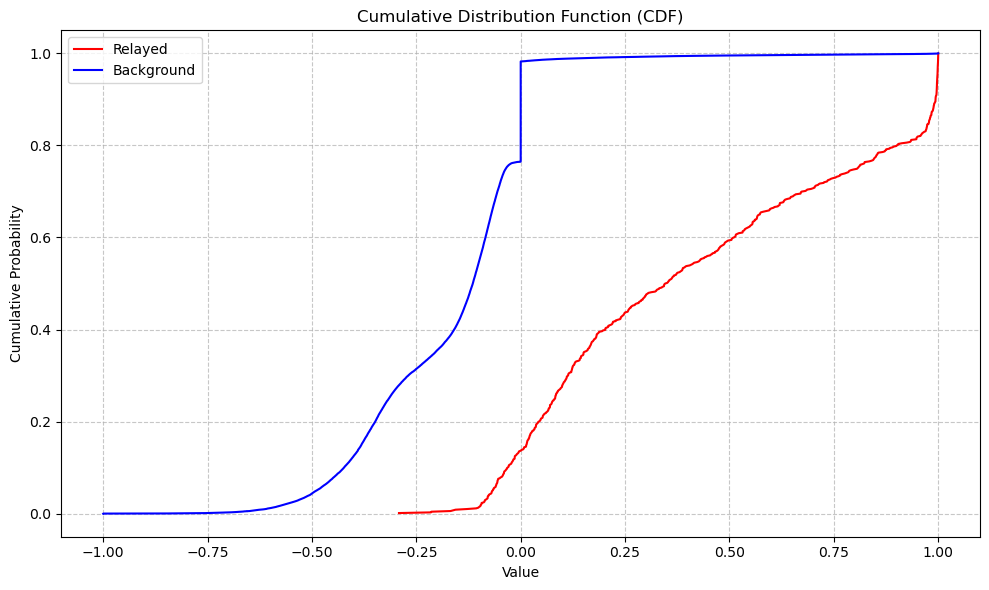

In [9]:
def plot_cdf(data1, data2, label1='Relayed', label2='Background'):
    # Create a figure
    plt.figure(figsize=(10, 6))
    
    # Calculate CDFs for both datasets
    sorted_data1 = np.sort(data1)
    cdf1 = np.arange(1, len(sorted_data1) + 1) / len(sorted_data1)
    
    sorted_data2 = np.sort(data2)
    cdf2 = np.arange(1, len(sorted_data2) + 1) / len(sorted_data2)
    
    # Plot CDFs
    plt.plot(sorted_data1, cdf1, label=label1, color='red')
    plt.plot(sorted_data2, cdf2, label=label2, color='blue')
    
    # Customize plot
    plt.xlabel('Value')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Distribution Function (CDF)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Show plot
    plt.tight_layout()
    plt.show()

# Assuming the correlation values are in a column called 'corr_mean'
# Adjust the column name as needed
plot_cdf(rel_test_corr['corr_mean'], bg_test_corr['corr_mean'])

In [10]:
train_slt = pd.read_csv('data/feats/subset/train/features.csv')
test_slt = pd.read_csv('data/feats/subset/test/features.csv')
val_slt = pd.read_csv('data/feats/subset/val/features.csv')

In [5]:
test_corr_df

,corr_count,corr_sum,corr_mean,corr_median,corr_minimum,corr_maximum,corr_range,corr_variance,corr_std_dev,label
0,101,-5.713629,-0.056571,0.049197,-3.048048,0.056363,3.104411,0.142517,0.377514,0
1,106,-6.131595,-0.057845,0.049334,-3.151295,0.057623,3.208918,0.138558,0.372233,0
2,39,-3.453160,-0.088543,0.056693,-3.252374,0.088262,3.340636,0.299301,0.547084,0
3,102,-4.625365,-0.045347,0.039442,-3.304471,0.045179,3.349650,0.134198,0.366330,0
4,108,-8.320041,-0.077037,0.065896,-2.458223,0.076735,2.534958,0.154780,0.393420,0
...,...,...,...,...,...,...,...,...,...,...
681,8,7.978032,0.997254,0.338825,0.013085,6.384200,6.371115,4.756741,2.180995,1
682,13,12.998123,0.999856,0.235798,0.009431,9.280207,9.270776,6.358090,2.521525,1
683,22,21.934307,0.997014,0.688810,0.004468,4.542054,4.537585,1.630252,1.276813,1
684,43,19.515692,0.453853,0.095385,-1.332787,14.360197,15.692984,5.241115,2.289348,1


In [7]:
test_df = test_corr_df
train_df = pd.concat([train_corr_df, val_corr_df])
# val_df = val_corr_df

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from math import sqrt

# Assuming val_df is already loaded
# Process validation data similarly to train and test
# X_val = val_df.drop(columns=['label']).reset_index(drop=True)
# y_val = val_df['label']

# Prepare training data
train_df = train_df.sample(frac=1).reset_index(drop=True)
train_df = train_df.astype(float)
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

# Prepare test data
X_test = test_df.drop(columns=['label']).reset_index(drop=True)
y_test = test_df['label']

# Calculate scale_pos_weight
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = sqrt(negative_count / positive_count)
print(f"Scale pos weight: {scale_pos_weight}")


# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    # scale_pos_weight=scale_pos_weight,
    random_state=42,
)

# Train the model with early stopping using validation data
xgb_model.fit(
    X_train, y_train,
    verbose=True  # Print evaluation results
)

# Make predictions on test set
y_pred = xgb_model.predict(X_test)
print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix for test set
cf = confusion_matrix(y_test, y_pred)
print(cf)
TN = cf[0][0]
FP = cf[0][1]
print("FPR (%): ", FP/(TN + FP) * 100)

Scale pos weight: 5.346391763848481

Test Results:
Accuracy: 0.9919033409152563

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47235
           1       0.70      0.77      0.73       686

    accuracy                           0.99     47921
   macro avg       0.85      0.88      0.86     47921
weighted avg       0.99      0.99      0.99     47921

[[47007   228]
 [  160   526]]
FPR (%):  0.48269291838678946


In [55]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------
# Use previously defined dataframes:
#   - train_df, val_df, test_df
#   (Assuming they contain the 'label' column and 'corr_mean' feature)
# ---------------------------

# Process validation data
X_val = val_df.drop(columns=['label']).reset_index(drop=True)
y_val = val_df['label']

# Process test data
X_test = test_df.drop(columns=['label']).reset_index(drop=True)
y_test = test_df['label']

# ---------------------------
# Simple classifier based solely on the 'corr_mean' feature:
# If corr_mean > 0, predict positive class (1); otherwise predict negative class (0)
# ---------------------------

# Predict on the validation set
y_val_pred = (X_val['corr_mean'] > 0).astype(int)

print("\nValidation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Confusion matrix for the validation set
cf_val = confusion_matrix(y_val, y_val_pred)
print("\nValidation Confusion Matrix:")
print(cf_val)
TN_val = cf_val[0][0]
FP_val = cf_val[0][1]
print("Validation FPR (%):", FP_val / (TN_val + FP_val) * 100)

# Predict on the test set
y_pred = (X_test['corr_mean'] > 0).astype(int)

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix for the test set
cf = confusion_matrix(y_test, y_pred)
print("\nTest Confusion Matrix:")
print(cf)
TN = cf[0][0]
FP = cf[0][1]
print("Test FPR (%):", FP / (TN + FP) * 100)



Validation Results:
Accuracy: 0.9752844667901561

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     36565
           1       0.58      0.86      0.69      1225

    accuracy                           0.98     37790
   macro avg       0.79      0.92      0.84     37790
weighted avg       0.98      0.98      0.98     37790


Validation Confusion Matrix:
[[35807   758]
 [  176  1049]]
Validation FPR (%): 2.0730206481608096

Test Results:
Accuracy: 0.9806973978005468

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     47235
           1       0.42      0.86      0.56       686

    accuracy                           0.98     47921
   macro avg       0.71      0.92      0.78     47921
weighted avg       0.99      0.98      0.98     47921


Test Confusion Matrix:
[[46403   832]
 [   93   593]]
Test FPR (%): 1.7614057372710914


In [148]:
background_df

,conn,server_name,ts_relative,src_ip,src_port,dst_ip,dst_port,pkt_len,App name
0,normal_conn_1,accounts.google.com,6.801001,10.0.2.16,50754,142.250.27.84,443,60,Chrome
1,normal_conn_1,accounts.google.com,6.927180,142.250.27.84,443,10.0.2.16,50754,44,Chrome
2,normal_conn_1,accounts.google.com,6.927201,10.0.2.16,50754,142.250.27.84,443,40,Chrome
3,normal_conn_1,accounts.google.com,6.927904,10.0.2.16,50754,142.250.27.84,443,557,Chrome
4,normal_conn_1,accounts.google.com,6.928062,142.250.27.84,443,10.0.2.16,50754,40,Chrome
...,...,...,...,...,...,...,...,...,...
1727721,normal_conn_9163,www.clarity.ms,7409.331927,10.0.2.16,39596,13.107.246.67,443,40,Chrome
1727722,normal_conn_9163,www.clarity.ms,7409.332014,13.107.246.67,443,10.0.2.16,39596,111,Chrome
1727723,normal_conn_9163,www.clarity.ms,7409.332018,10.0.2.16,39596,13.107.246.67,443,40,Chrome
1727724,normal_conn_9163,www.clarity.ms,7409.332059,10.0.2.16,39596,13.107.246.67,443,71,Chrome


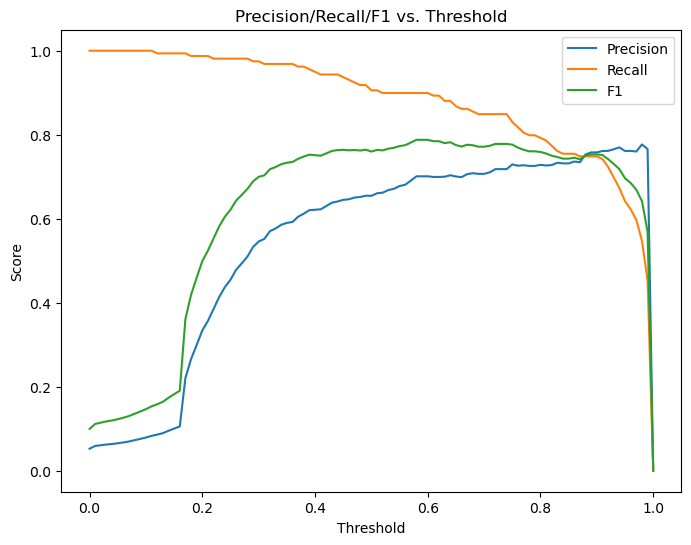

Best threshold for max F1: 0.58 F1: 0.7878787878787878
Confusion Matrix:
[[2814   61]
 [  16  143]]

Classification Report:
              precision    recall  f1-score   support

           0      0.994     0.979     0.987      2875
           1      0.701     0.899     0.788       159

    accuracy                          0.975      3034
   macro avg      0.848     0.939     0.887      3034
weighted avg      0.979     0.975     0.976      3034

False Positive Rate: 2.12%
corr_count: 0.8237
corr_sum: 0.7184
corr_mean: 1.1773
corr_median: 1.7881
corr_minimum: 0.7338
corr_maximum: 0.6117
corr_range: 0.1303
corr_variance: -1.1006
corr_std_dev: 0.4662


In [114]:
# 1. Get predicted probabilities for the positive class
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []
f1s = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh, zero_division=0)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

# 2. Plot the precision-recall as a function of threshold
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs. Threshold')
plt.legend()
plt.show()

# 3. Pick the threshold you want (example: maximize F1 or get a desired precision)
best_idx = np.argmax(f1s)  # or pick for precision >= some value
best_thresh = thresholds[best_idx]
print("Best threshold for max F1:", best_thresh, "F1:", f1s[best_idx])

final_threshold = 0.7  # as an example
y_pred_final = (y_proba >= best_thresh).astype(int)

print("Confusion Matrix:")
cf_matrix =confusion_matrix(y_test, y_pred_final)
print(cf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, digits=3))

fp = cf_matrix[0][1]/(cf_matrix[0][0] + cf_matrix[0][1]) * 100
print(f"False Positive Rate: {fp:.2f}%")

# 7. Check feature importance (for logistic regression):
clf = best_model.named_steps['clf']
coeffs = clf.coef_[0]
feature_names = X.columns
for name, coef in zip(feature_names, coeffs):
    print(f"{name}: {coef:.4f}")



Ray tune section

In [84]:
relayed_df['conn'].value_counts()

conn
normal_conn_16233    766
normal_conn_15657    545
normal_conn_12284    544
normal_conn_11106    541
normal_conn_21554    539
                    ... 
normal_conn_7247       8
normal_conn_17476      8
normal_conn_7931       8
normal_conn_7927       7
normal_conn_7634       6
Name: count, Length: 352, dtype: int64

In [85]:
relayed_conn_4775 = relayed_df[relayed_df['conn'] == 'normal_conn_16233']

In [86]:
relayed_conn_4775_sorted = relayed_conn_4775.sort_values(by='ts_relative')
conn_ts_start = relayed_conn_4775_sorted['ts_relative'].min()
conn_ts_end = relayed_conn_4775_sorted['ts_relative'].max()
relayed_conn_4775

,conn,server_name,ts_relative,src_ip,src_port,dst_ip,dst_port,pkt_len,App name
67572,normal_conn_16233,images.footlocker.com,4954.967545,199.232.82.132,443,10.0.2.16,43703,44,EarnApp
67576,normal_conn_16233,images.footlocker.com,4955.160190,199.232.82.132,443,10.0.2.16,43703,40,EarnApp
67577,normal_conn_16233,images.footlocker.com,4955.160200,199.232.82.132,443,10.0.2.16,43703,40,EarnApp
67578,normal_conn_16233,images.footlocker.com,4955.286034,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp
67580,normal_conn_16233,images.footlocker.com,4955.286054,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp
...,...,...,...,...,...,...,...,...,...
68902,normal_conn_16233,images.footlocker.com,4956.435118,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp
68903,normal_conn_16233,images.footlocker.com,4956.435122,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp
68904,normal_conn_16233,images.footlocker.com,4956.435125,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp
68905,normal_conn_16233,images.footlocker.com,4956.435128,199.232.82.132,443,10.0.2.16,43703,1480,EarnApp


In [87]:
new_gw = gateway_df[(gateway_df['ts_relative'] >= conn_ts_start) & (gateway_df['ts_relative'] <= conn_ts_end)]
# new_gw = new_gw[new_gw['pkt_len'] >= 300]
new_gw_sorted = new_gw.sort_values(by='ts_relative')
new_gw_sorted

,conn,server_name,ts_relative,src_ip,src_port,dst_ip,dst_port,pkt_len,bin
86841,proxy_conn_160,217-69-10-110.brdtnet.com,4954.968247,10.0.2.16,56443,217.69.10.110,443,292,2477
86844,proxy_conn_160,217-69-10-110.brdtnet.com,4954.988969,10.0.2.16,56443,217.69.10.110,443,40,2477
86846,proxy_conn_160,217-69-10-110.brdtnet.com,4954.994258,10.0.2.16,56443,217.69.10.110,443,40,2477
86848,proxy_conn_160,217-69-10-110.brdtnet.com,4955.058593,10.0.2.16,56443,217.69.10.110,443,40,2477
86850,proxy_conn_160,217-69-10-110.brdtnet.com,4955.062601,10.0.2.16,56443,217.69.10.110,443,40,2477
...,...,...,...,...,...,...,...,...,...
88215,proxy_conn_160,217-69-10-110.brdtnet.com,4956.434778,10.0.2.16,56443,217.69.10.110,443,86,2478
88217,proxy_conn_160,217-69-10-110.brdtnet.com,4956.434826,10.0.2.16,56443,217.69.10.110,443,138,2478
88219,proxy_conn_160,217-69-10-110.brdtnet.com,4956.435016,10.0.2.16,56443,217.69.10.110,443,86,2478
88221,proxy_conn_160,217-69-10-110.brdtnet.com,4956.435070,10.0.2.16,56443,217.69.10.110,443,123,2478


In [13]:
bin_size_seconds = 3
# Create time bins for gateway_conn_df and conn_df
new_gw_sorted.loc[:, 'time_bin'] = (new_gw_sorted['ts_relative'] // bin_size_seconds) * bin_size_seconds
relayed_conn_4775_sorted.loc[:, 'time_bin'] = (relayed_conn_4775_sorted['ts_relative'] // bin_size_seconds) * bin_size_seconds

# Count number of occurrences per bin for gateway and relay
gateway_counts = new_gw_sorted.groupby('time_bin').size()
relay_counts = relayed_conn_4775_sorted.groupby('time_bin').size()

In [14]:
gateway_counts

time_bin
2802.0      1
2805.0    137
2808.0    254
2811.0    391
2814.0     53
2817.0     92
dtype: int64

In [88]:
background_df[(background_df['ts_relative'] >= conn_ts_start) & (background_df['ts_relative'] <= conn_ts_end)]

,conn,server_name,ts_relative,src_ip,src_port,dst_ip,dst_port,pkt_len,App name
2717754,normal_conn_15747,fls-fe.amazon.co.jp,4956.057712,54.184.72.67,443,10.0.2.16,40226,40,Chrome
2717755,normal_conn_15747,fls-fe.amazon.co.jp,4956.057726,54.184.72.67,443,10.0.2.16,40226,40,Chrome
2717756,normal_conn_15747,fls-fe.amazon.co.jp,4956.057729,54.184.72.67,443,10.0.2.16,40226,40,Chrome
2717757,normal_conn_15747,fls-fe.amazon.co.jp,4956.347668,54.184.72.67,443,10.0.2.16,40226,86,Chrome
2717759,normal_conn_15747,fls-fe.amazon.co.jp,4956.349637,54.184.72.67,443,10.0.2.16,40226,247,Chrome
